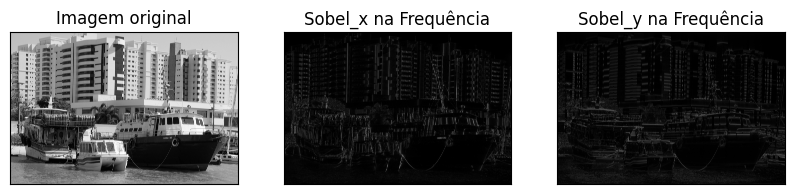

In [3]:
# Importando Bibliotecas
import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy import signal
import random
img = cv2.imread('portinho.jpg',0)
fourier = np.fft.fft2(img)
fourier1 =np.log(1+np.abs(fourier))
phase=np.angle(fourier)
center = np.fft.fftshift(fourier)
inv_center = np.fft.ifftshift(center)
processed_img = np.fft.ifft2(inv_center)
# Gerando Filtro de Sobel no espaço e aplicando no Domínio da Frequência
# Sobel em x
sobelx=np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
(h,w)=img.shape
# kernel = cv2.getGaussianKernel(11, 3)
# kernel = kernel * kernel.T
ftkernel = np.fft.fftshift(np.fft.fft2(sobelx, (h, w)))  #função q joga o kernel para o tamanho ideal
kernel_vis=np.log(1+np.abs(ftkernel))
# Sobel em y
sobely=sobelx.T
ftkernely = np.fft.fftshift(np.fft.fft2(sobely, (h, w)))  #função q joga o kernel para o tamanho ideal
kernel_visy=np.log(1+np.abs(ftkernely))
# Filtragem
# Na direção x
Sobel=center*kernel_vis # filtragem com Sobel na direção x
SobelShift = np.fft.ifftshift(Sobel)  # Volta do espectro filtrado para os cantos
inverse_Sobel = np.fft.ifft2(SobelShift) # Inversa de Fourier
# Na direção y
Sobely=center*kernel_visy # filtragem com Sobel na direção x
SobelShifty = np.fft.ifftshift(Sobely)  # Volta do espectro filtrado para os cantos
inverse_Sobely = np.fft.ifft2(SobelShifty) # Inversa de Fourier
#Resultados da Filtragem de Sobel na Frequência
plt.figure(figsize=(10,12))
plt.subplot (1,3,1)
plt.imshow(img,cmap=plt.cm.gray)
plt.title('Imagem original'),plt.xticks([]), plt.yticks([])
plt.subplot (1,3,2)
plt.imshow(np.abs(inverse_Sobel),cmap=plt.cm.gray)
plt.title('Sobel_x na Frequência'),plt.xticks([]), plt.yticks([])
plt.subplot (1,3,3)
plt.imshow(np.abs(inverse_Sobely),cmap=plt.cm.gray)
plt.title('Sobel_y na Frequência'),plt.xticks([]), plt.yticks([])
plt.show()


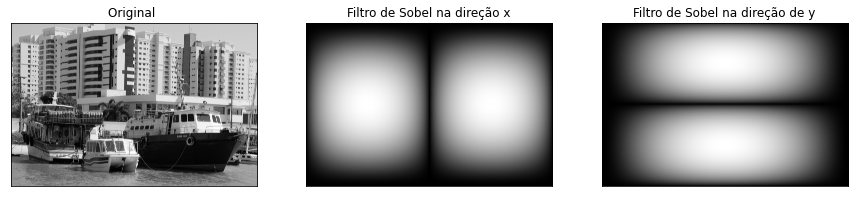

In [ ]:
# Gerando Resultados
plt.figure(figsize=(15,10))
plt.subplot (1,3,1)
plt.imshow(img,cmap=plt.cm.gray)
plt.title('Original '),plt.xticks([]), plt.yticks([])
plt.subplot (1,3,2)
plt.imshow(kernel_vis,cmap=plt.cm.gray)
plt.title('Filtro de Sobel na direção x'),plt.xticks([]), plt.yticks([])
plt.subplot (1,3,3)
plt.imshow(kernel_visy,cmap=plt.cm.gray)
plt.title('Filtro de Sobel na direção de y'),plt.xticks([]), plt.yticks([])
plt.show()

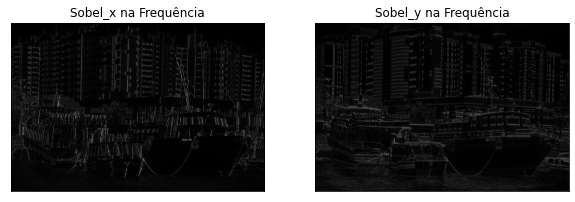

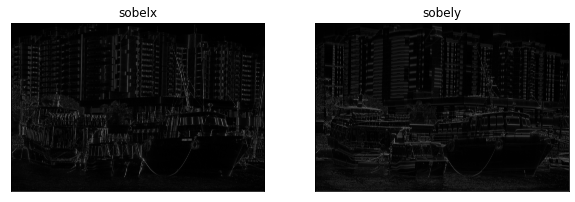

In [ ]:
#Resultados da Filtragem de Sobel no Dominio Espacial
plt.figure(figsize=(10,12))
plt.subplot (1,2,1)
plt.imshow(np.abs(inverse_Sobel),cmap=plt.cm.gray)
plt.title('sobelx'),plt.xticks([]), plt.yticks([])
plt.subplot (1,2,2)
plt.imshow(np.abs(inverse_Sobely),cmap=plt.cm.gray)
plt.title('sobely'),plt.xticks([]), plt.yticks([])
plt.show()